# Optics Laboratory Simulation


1) An optical system consists of two thick lenses (medium around is air), the first lens has refractive index $n_1 = 1.50$, thickness: $t_1 = 5mm$ surface radii

$$
R_1 = + 40mm
$$
$$
R_2 = - 40mm
$$

And lens 2 is a discance $d_{12} = 30mm$ (distance vertex to vertex), refractive index: $n_2 = 1.6$, thickness: $t_2 = 4mm$, surface radii

$$
    R_3 = +25mm
$$
$$
    R_4 = -35mm
$$

## Computing values

For calculating the focal points, we find the following:

$$
\frac{1}{f} = (n_l - 1 ) \left( \frac{1}{R_1} - \frac{1}{R_2} + \frac{(n_l - 1)t}{n_l R_1 R_2} \right)
$$
$$
\implies f_1 = \boxed{+40.85mm}
$$
$$
\implies f_2 = \boxed{+24.93mm}
$$

For calculating the principle planes we use the following formula:

$$
h_n = - \frac{f(n - 1)t}{n R_n}
$$

$$
\implies h_{11} = \boxed{-1.702mm}
$$

$$
\implies h_{12} = \boxed{1.702mm}
$$

$$
\implies h_{21} = \boxed{-1.496mm}
$$

$$
\implies h_{22} = \boxed{1.068mm}
$$


## Using Matrix Formalism

For a thick lens (in air):

$$
M = \begin{bmatrix}
1 & 0 \\
\frac{n_l-1}{R_2} & n
\end{bmatrix}
\begin{bmatrix}
1 & t \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
1 & 0 \\
\frac{n_l-1}{R_1} & n
\end{bmatrix}
$$

Now, in between the lenses we can add a translation matrix:

$$
T_{12} = \begin{bmatrix}
1 & d_{12} \\
0 & 1
\end{bmatrix}
$$

In [30]:
import numpy as np

def refraction_matrix(n, R):
    return np.array([[1,0],[(n-1)/R, n]])

def translation_matrix(d):
    return np.array([[1,d],[0,1]])

def thick_lens_matrix(n, R1, R2, t):
    refraction1 = refraction_matrix(n, R1)
    refraction2 = refraction_matrix(n, R2)
    translation = translation_matrix(t)
    return refraction2 @ translation @ refraction1
    
def calc_raypath(coords):
    # arrange optical system
    [height, angle] = coords
    lens1 = thick_lens_matrix(1.5, 40, -40, 5)
    air1 = translation_matrix(30)
    lens2 = thick_lens_matrix(1.6, 25, -35, 4)
    coords = np.array([height, angle])
    return lens2 @ air1 @ lens1 @ coords

def convert_to_xy(coords, x0, xf):
    return [x0, xf], [coords[0],coords[0] + (xf-x0)*np.sin(coords[1])]

incoming = [ [0, 0], [1,0], [-1,0], [0, .5], [0, -.5] ]
outgoing = [ calc_raypath(coord) for coord in incoming ]

incoming, outgoing

([[0, 0], [1, 0], [-1, 0], [0, 0.5], [0, -0.5]],
 [array([0., 0.]),
  array([1.3793125 , 0.03745464]),
  array([-1.3793125 , -0.03745464]),
  array([46.45875   ,  3.34956429]),
  array([-46.45875   ,  -3.34956429])])

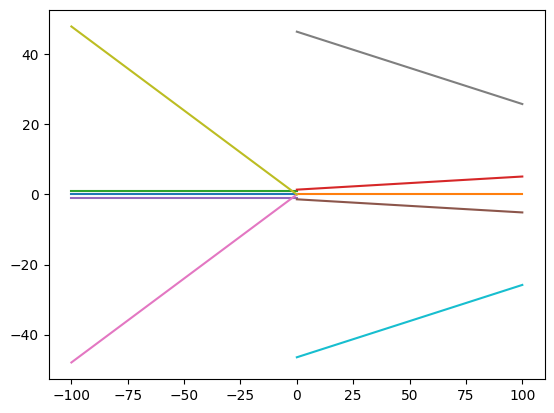

In [31]:
import matplotlib.pyplot as plt

for i in range(len(incoming)):

    y0 = incoming[i][0]
    angle = incoming[i][1]
    incoming_x = [-100, 0]
    incoming_y = [y0 - np.sin(angle)*100, y0]

    y0 = outgoing[i][0]
    angle = outgoing[i][1]
    outgoing_x = [0, 100]
    outgoing_y = [y0, y0 + np.sin(angle)*100]
    
    plt.plot(incoming_x, incoming_y)
    plt.plot(outgoing_x, outgoing_y)

